# Q6: Will Goliaths Meet Their Climate Targets?

Q6 can be formulated as a **time-series forecasting** problem, where the goal is to predict future emissions trajectories for each country based on historical data. These forecasts are then evaluated against predefined policy targets to determine whether a country is on track.

We analyze two categories of targets introduced in Q2:

1. Absolute reduction targets (emissions levels by a given year)
2. Net-zero targets (long-term convergence toward zero emissions)

To assess these, we apply two complementary forecasting approaches:

1. Linear regression - used as a baseline model, representing a continuation of historical trends under a constant rate of change
2. Prophet - used as the primary model, allowing for non-linear trend dynamics such as peaks, slowdowns, and structural shifts

Linear regression shows what happens if trends persist; Prophet shows whether the trajectory is actually changing.

In [298]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

## Loading the emissions dataset

We use the same OWID dataset structure as in the rest of the project:

- `entity`
- `code`
- `year`
- `emissions_total`

In [299]:
df = pd.read_csv(
    "https://ourworldindata.org/grapher/annual-co2-emissions-per-country.csv?v=1&csvType=full&useColumnShortNames=true",
    storage_options={"User-Agent": "Our World In Data data fetch/1.0"}
)

df = df[["entity", "code", "year", "emissions_total"]].copy()
df = df.dropna(subset=["emissions_total"])

# OWID grapher values are in tonnes of CO2.
# Convert to MtCO2 so that forecasts are directly comparable to the target table.
df["emissions_mtco2"] = df["emissions_total"] / 1_000_000

df.head()


,entity,code,year,emissions_total,emissions_mtco2
0,Afghanistan,AFG,1949,14656.0,0.014656
1,Afghanistan,AFG,1950,84272.0,0.084272
2,Afghanistan,AFG,1951,91600.0,0.091600
3,Afghanistan,AFG,1952,91600.0,0.091600
4,Afghanistan,AFG,1953,106256.0,0.106256


In [300]:
missing_values = df.isnull().sum()
missing_values

entity                0
code               5670
year                  0
emissions_total       0
emissions_mtco2       0
dtype: int64

## Defining the target table

In Q2, we noticed different Goliaths have set different types of targets.
This analysis focuses on countries with absolute emissions reduction targets, as these provide a clear, comparable threshold in MtCO₂ against which model forecasts can be directly evaluated.

The included Goliaths:

- United States
- Russia
- Germany
- Japan
- United Kingdom
- France
- Ukraine
- China

India define their commitments in terms of emissions intensity or peak targets, which depend on future economic growth and do not translate into a fixed emissions level. Similarly, Saudi Arabia and Iran define targets relative to dynamic baselines or lack sufficient data to derive an absolute threshold. For the purpose of this notebook, we will not include these countries and leave their analysis to future work.

In [301]:
targets = pd.DataFrame([
    {"country": "United States", "target_year": 2030, "target_type": "absolute_reduction", "baseline_year": 2005, "baseline_emissions_mtco2": 6126.9, "reduction_pct": 50, "target_absolute_mtco2": 3063.5, "net_zero_year": 2050, "target_quality": "unclear"},
    {"country": "United States", "target_year": 2035, "target_type": "absolute_reduction", "baseline_year": 2005, "baseline_emissions_mtco2": 6126.9, "reduction_pct": 61, "target_absolute_mtco2": 2389.5, "net_zero_year": 2050, "target_quality": "unclear"},
    {"country": "China", "target_year": 2030, "target_type": "peak", "baseline_year": pd.NA, "baseline_emissions_mtco2": np.nan, "reduction_pct": np.nan, "target_absolute_mtco2": np.nan, "net_zero_year": 2060, "target_quality": "unclear"},
    {"country": "Russia", "target_year": 2030, "target_type": "absolute_reduction", "baseline_year": 1990, "baseline_emissions_mtco2": 2536.3, "reduction_pct": 30, "target_absolute_mtco2": 1775.4, "net_zero_year": 2060, "target_quality": "weak"},
    {"country": "Germany", "target_year": 2030, "target_type": "absolute_reduction", "baseline_year": 1990, "baseline_emissions_mtco2": 1054.8, "reduction_pct": 65, "target_absolute_mtco2": 369.2, "net_zero_year": 2045, "target_quality": "strong"},
    {"country": "Japan", "target_year": 2030, "target_type": "absolute_reduction", "baseline_year": 2013, "baseline_emissions_mtco2": 1311.9, "reduction_pct": 46, "target_absolute_mtco2": 708.4, "net_zero_year": 2050, "target_quality": "strong"},
    {"country": "Japan", "target_year": 2035, "target_type": "absolute_reduction", "baseline_year": 2013, "baseline_emissions_mtco2": 1311.9, "reduction_pct": 60, "target_absolute_mtco2": 524.8, "net_zero_year": 2050, "target_quality": "strong"},
    {"country": "Japan", "target_year": 2040, "target_type": "absolute_reduction", "baseline_year": 2013, "baseline_emissions_mtco2": 1311.9, "reduction_pct": 73, "target_absolute_mtco2": 354.2, "net_zero_year": 2050, "target_quality": "strong"},
    {"country": "United Kingdom", "target_year": 2030, "target_type": "absolute_reduction", "baseline_year": 1990, "baseline_emissions_mtco2": 601.9, "reduction_pct": 68, "target_absolute_mtco2": 192.6, "net_zero_year": 2050, "target_quality": "strong"},
    {"country": "United Kingdom", "target_year": 2035, "target_type": "absolute_reduction", "baseline_year": 1990, "baseline_emissions_mtco2": 601.9, "reduction_pct": 81, "target_absolute_mtco2": 114.4, "net_zero_year": 2050, "target_quality": "strong"},
    {"country": "France", "target_year": 2030, "target_type": "absolute_reduction", "baseline_year": 1990, "baseline_emissions_mtco2": 394.9, "reduction_pct": 50, "target_absolute_mtco2": 197.5, "net_zero_year": 2050, "target_quality": "strong"},
    {"country": "Ukraine", "target_year": 2030, "target_type": "absolute_reduction", "baseline_year": 1990, "baseline_emissions_mtco2": 706.5, "reduction_pct": 65, "target_absolute_mtco2": 247.3, "net_zero_year": 2060, "target_quality": "strong"},
    {"country": "Ukraine", "target_year": 2035, "target_type": "absolute_reduction", "baseline_year": 1990, "baseline_emissions_mtco2": 706.5, "reduction_pct": 65, "target_absolute_mtco2": 247.3, "net_zero_year": 2050, "target_quality": "strong"},
])

targets


,country,target_year,target_type,baseline_year,baseline_emissions_mtco2,reduction_pct,target_absolute_mtco2,net_zero_year,target_quality
0,United States,2030,absolute_reduction,2005,6126.9,50.0,3063.5,2050,unclear
1,United States,2035,absolute_reduction,2005,6126.9,61.0,2389.5,2050,unclear
2,China,2030,peak,<NA>,NaN,NaN,NaN,2060,unclear
3,Russia,2030,absolute_reduction,1990,2536.3,30.0,1775.4,2060,weak
4,Germany,2030,absolute_reduction,1990,1054.8,65.0,369.2,2045,strong
5,Japan,2030,absolute_reduction,2013,1311.9,46.0,708.4,2050,strong
6,Japan,2035,absolute_reduction,2013,1311.9,60.0,524.8,2050,strong
7,Japan,2040,absolute_reduction,2013,1311.9,73.0,354.2,2050,strong
8,United Kingdom,2030,absolute_reduction,1990,601.9,68.0,192.6,2050,strong
9,United Kingdom,2035,absolute_reduction,1990,601.9,81.0,114.4,2050,strong


## Keeping only the countries we model in this notebook

The targets table may contain multiple rows per country because a country can have:
- multiple milestone years
- different target types (absolute, peak, intensity)

That is useful, but for this notebook we focus mainly on **absolute reduction targets**, because those can be directly compared to forecasted emissions.

In [302]:
goliaths = ["China", "United States", "Russia", "Japan", "Germany", "United Kingdom", "France", "Ukraine"]

targets_goliaths = targets[targets["country"].isin(goliaths)].copy()
targets_goliaths

,country,target_year,target_type,baseline_year,baseline_emissions_mtco2,reduction_pct,target_absolute_mtco2,net_zero_year,target_quality
0,United States,2030,absolute_reduction,2005,6126.9,50.0,3063.5,2050,unclear
1,United States,2035,absolute_reduction,2005,6126.9,61.0,2389.5,2050,unclear
2,China,2030,peak,<NA>,NaN,NaN,NaN,2060,unclear
3,Russia,2030,absolute_reduction,1990,2536.3,30.0,1775.4,2060,weak
4,Germany,2030,absolute_reduction,1990,1054.8,65.0,369.2,2045,strong
5,Japan,2030,absolute_reduction,2013,1311.9,46.0,708.4,2050,strong
6,Japan,2035,absolute_reduction,2013,1311.9,60.0,524.8,2050,strong
7,Japan,2040,absolute_reduction,2013,1311.9,73.0,354.2,2050,strong
8,United Kingdom,2030,absolute_reduction,1990,601.9,68.0,192.6,2050,strong
9,United Kingdom,2035,absolute_reduction,1990,601.9,81.0,114.4,2050,strong


## Fiting a simple linear regression baseline

For each country, we fit:

\[
emissions = a + b \cdot year
\]

This is intentionally simple.  
Its role is to answer:

> If historical emissions continue linearly, where will the country be by the target year?

In [303]:
def fit_linear_model(country):
    country_df = df[df["entity"] == country].copy().sort_values("year")

    X = country_df[["year"]]
    y = country_df["emissions_mtco2"]

    model = LinearRegression()
    model.fit(X, y)

    return model, country_df

def forecast_for_year(country, year):
    model, country_df = fit_linear_model(country)
    pred = model.predict(pd.DataFrame({"year": [year]}))[0]
    return pred


## Forecasting each target

In our targets table, we notice different countries made multiple promises.

We forecast emissions **for the target year in each row**.
This means:
- US 2030 forecast
- US 2035 forecast
- Japan 2030 / 2035 / 2040 forecast
- etc.

In [304]:
targets_goliaths["forecast_mtco2"] = targets_goliaths.apply(
    lambda r: forecast_for_year(r["country"], int(r["target_year"])),
    axis=1
)

targets_goliaths


,country,target_year,target_type,baseline_year,baseline_emissions_mtco2,reduction_pct,target_absolute_mtco2,net_zero_year,target_quality,forecast_mtco2
0,United States,2030,absolute_reduction,2005,6126.9,50.0,3063.5,2050,unclear,5464.650212
1,United States,2035,absolute_reduction,2005,6126.9,61.0,2389.5,2050,unclear,5614.307411
2,China,2030,peak,<NA>,NaN,NaN,NaN,2060,unclear,7915.341725
3,Russia,2030,absolute_reduction,1990,2536.3,30.0,1775.4,2060,weak,1981.775153
4,Germany,2030,absolute_reduction,1990,1054.8,65.0,369.2,2045,strong,1039.518611
5,Japan,2030,absolute_reduction,2013,1311.9,46.0,708.4,2050,strong,1270.450547
6,Japan,2035,absolute_reduction,2013,1311.9,60.0,524.8,2050,strong,1319.680323
7,Japan,2040,absolute_reduction,2013,1311.9,73.0,354.2,2050,strong,1368.910098
8,United Kingdom,2030,absolute_reduction,1990,601.9,68.0,192.6,2050,strong,663.728925
9,United Kingdom,2035,absolute_reduction,1990,601.9,81.0,114.4,2050,strong,676.754482


## Baseline evaluation 

For this first version, evaluation depends on target type:

### Absolute reduction
We can directly compare:
- `forecast_mtco2`
- `target_absolute_mtco2`

### Peak target
For China's peak target, the first baseline question is:
> Is the forecasted 2030 value lower than the recent rising trajectory / has the trend flattened enough?

In [305]:
def evaluate_row(row):
    if row["target_type"] == "absolute_reduction" and pd.notna(row["target_absolute_mtco2"]):
        return row["forecast_mtco2"] <= row["target_absolute_mtco2"]
    return pd.NA

targets_goliaths["on_track_linear_baseline"] = targets_goliaths.apply(evaluate_row, axis=1)
targets_goliaths["gap_mtco2"] = targets_goliaths["forecast_mtco2"] - targets_goliaths["target_absolute_mtco2"]

targets_goliaths


,country,target_year,target_type,baseline_year,baseline_emissions_mtco2,reduction_pct,target_absolute_mtco2,net_zero_year,target_quality,forecast_mtco2,on_track_linear_baseline,gap_mtco2
0,United States,2030,absolute_reduction,2005,6126.9,50.0,3063.5,2050,unclear,5464.650212,False,2401.150212
1,United States,2035,absolute_reduction,2005,6126.9,61.0,2389.5,2050,unclear,5614.307411,False,3224.807411
2,China,2030,peak,<NA>,NaN,NaN,NaN,2060,unclear,7915.341725,<NA>,NaN
3,Russia,2030,absolute_reduction,1990,2536.3,30.0,1775.4,2060,weak,1981.775153,False,206.375153
4,Germany,2030,absolute_reduction,1990,1054.8,65.0,369.2,2045,strong,1039.518611,False,670.318611
5,Japan,2030,absolute_reduction,2013,1311.9,46.0,708.4,2050,strong,1270.450547,False,562.050547
6,Japan,2035,absolute_reduction,2013,1311.9,60.0,524.8,2050,strong,1319.680323,False,794.880323
7,Japan,2040,absolute_reduction,2013,1311.9,73.0,354.2,2050,strong,1368.910098,False,1014.710098
8,United Kingdom,2030,absolute_reduction,1990,601.9,68.0,192.6,2050,strong,663.728925,False,471.128925
9,United Kingdom,2035,absolute_reduction,1990,601.9,81.0,114.4,2050,strong,676.754482,False,562.354482


## Summarizing the results

After computing targets and forecasting with linear regression, this is our output:

In [306]:
summary_cols = [
    "country",
    "target_year",
    "target_type",
    "target_absolute_mtco2",
    "forecast_mtco2",
    "gap_mtco2",
    "on_track_linear_baseline",
    "net_zero_year",
    "target_quality"
]

summary = targets_goliaths[summary_cols].copy()
summary


,country,target_year,target_type,target_absolute_mtco2,forecast_mtco2,gap_mtco2,on_track_linear_baseline,net_zero_year,target_quality
0,United States,2030,absolute_reduction,3063.5,5464.650212,2401.150212,False,2050,unclear
1,United States,2035,absolute_reduction,2389.5,5614.307411,3224.807411,False,2050,unclear
2,China,2030,peak,NaN,7915.341725,NaN,<NA>,2060,unclear
3,Russia,2030,absolute_reduction,1775.4,1981.775153,206.375153,False,2060,weak
4,Germany,2030,absolute_reduction,369.2,1039.518611,670.318611,False,2045,strong
5,Japan,2030,absolute_reduction,708.4,1270.450547,562.050547,False,2050,strong
6,Japan,2035,absolute_reduction,524.8,1319.680323,794.880323,False,2050,strong
7,Japan,2040,absolute_reduction,354.2,1368.910098,1014.710098,False,2050,strong
8,United Kingdom,2030,absolute_reduction,192.6,663.728925,471.128925,False,2050,strong
9,United Kingdom,2035,absolute_reduction,114.4,676.754482,562.354482,False,2050,strong


## Visualizing the actual trend + baseline forecast + target

For countries with absolute targets, this chart makes the baseline logic easier to explain in presentation.

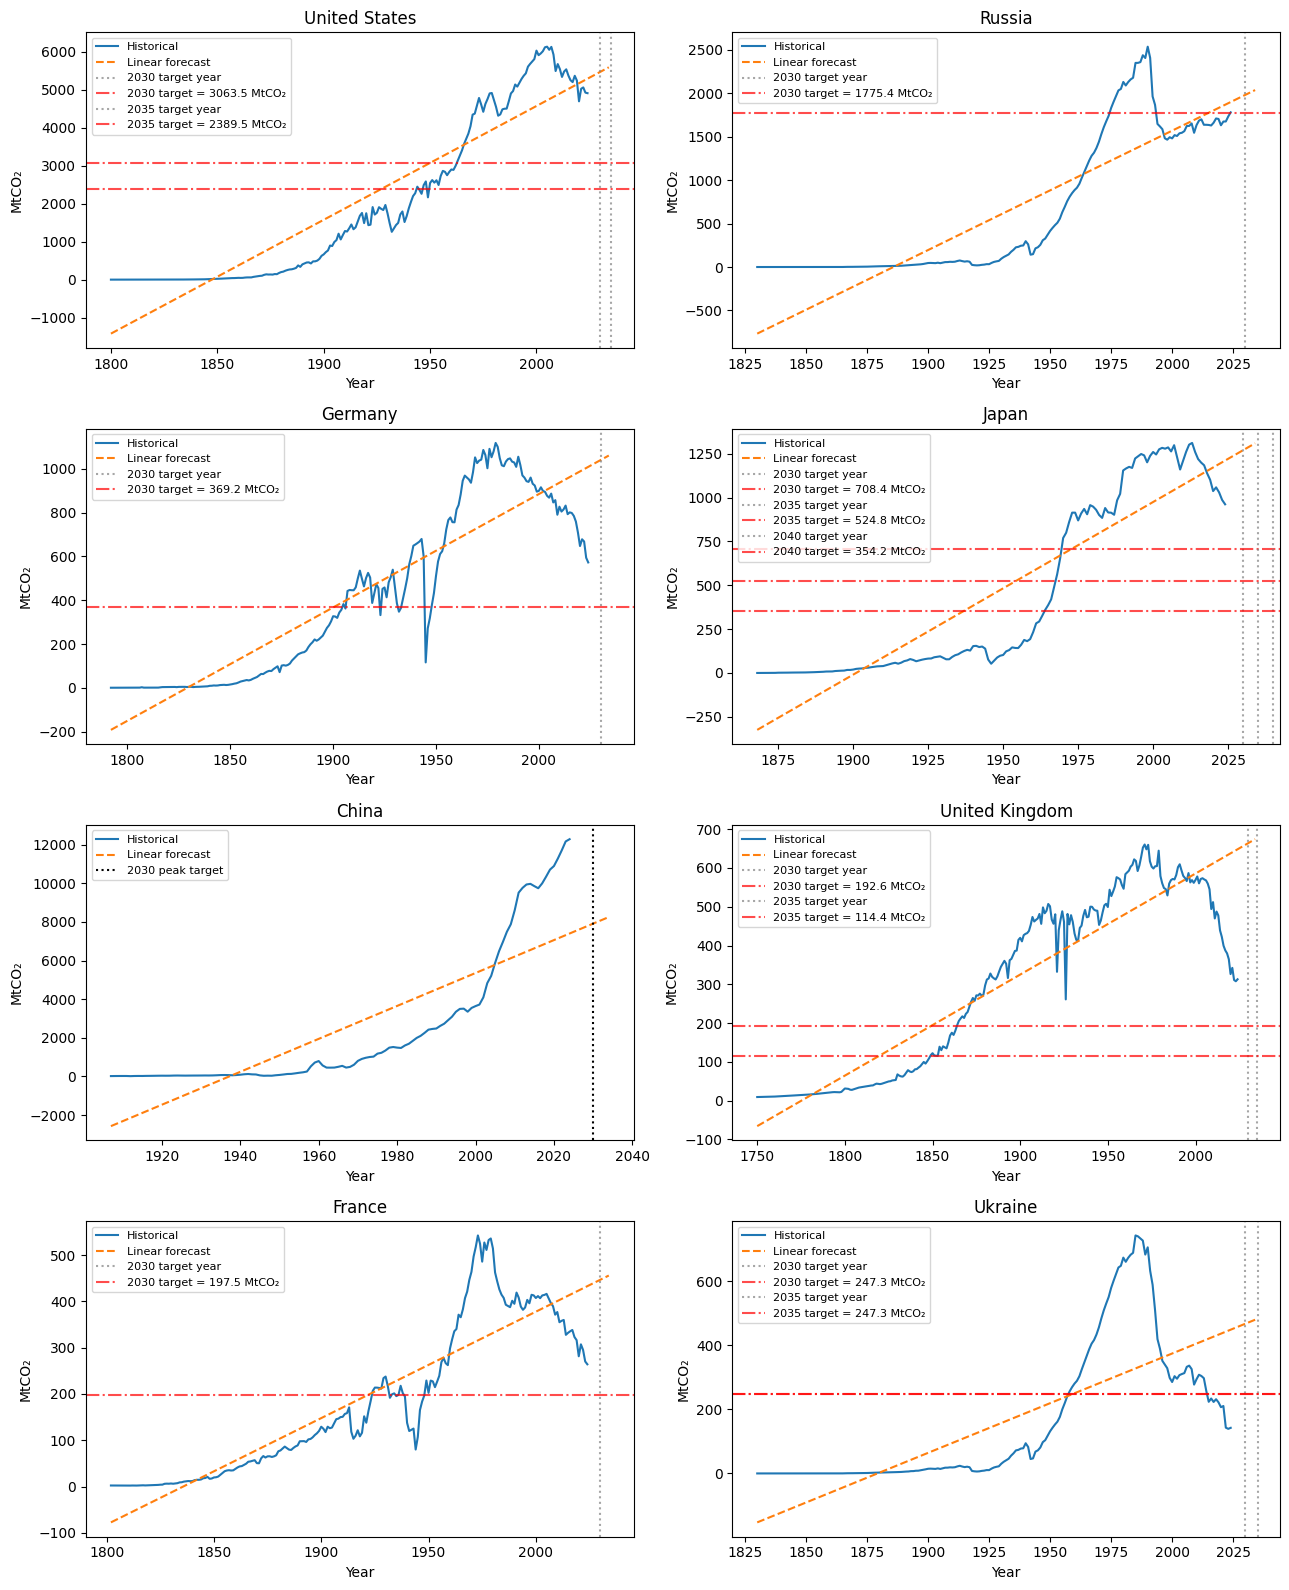

In [307]:
absolute_targets = targets_goliaths[targets_goliaths["target_type"] == "absolute_reduction"].copy()

countries = ["United States", "Russia", "Germany", "Japan", "China", "United Kingdom", "France", "Ukraine"]

n = len(countries)
cols = 2
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(13, 4 * rows))
axes = np.array(axes).reshape(-1)

for i, country in enumerate(countries):
    ax = axes[i]
    
    country_df = df[df["entity"] == country].copy().sort_values("year")
    model, _ = fit_linear_model(country)

    years_hist = country_df["year"].values
    years_future = np.arange(country_df["year"].min(), 2035)
    preds = model.predict(pd.DataFrame({"year": years_future}))

    ax.plot(years_hist, country_df["emissions_mtco2"], label="Historical")
    ax.plot(years_future, preds, linestyle="--", label="Linear forecast")

    if country != "China":
        country_targets = absolute_targets[absolute_targets["country"] == country].copy()
        country_targets = country_targets.sort_values("target_year")

        for _, row in country_targets.iterrows():
            year = int(row["target_year"])
            target_val = row["target_absolute_mtco2"]

            ax.axvline(year, linestyle=":", color="gray", alpha=0.7,
                       label=f"{year} target year")

            if pd.notna(target_val):
                ax.axhline(target_val, linestyle="-.", color="red", alpha=0.7,
                           label=f"{year} target = {target_val:.1f} MtCO₂")

    else:
        # China: peak target only
        ax.axvline(2030, linestyle=":", color="black",
                   label="2030 peak target")

    # clean legend (remove duplicates)
    handles, labels = ax.get_legend_handles_labels()
    unique = dict(zip(labels, handles))
    ax.legend(unique.values(), unique.keys(), fontsize=8)

    ax.set_title(country)
    ax.set_xlabel("Year")
    ax.set_ylabel("MtCO₂")

# remove empty subplot
for j in range(len(countries), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [308]:
china_df = df[df["entity"] == "China"]

# peak
peak_row = china_df.loc[china_df["emissions_mtco2"].idxmax()]

# last available year
last_year = china_df["year"].max()

print(f"Peak year ({int(peak_row['year'])}) vs last year ({int(last_year)})")

Peak year (2024) vs last year (2024)


## Interpretation: Linear baseline vs targets across Goliaths

The comparison of historical emissions, linear forecasts, and policy targets reveals a consistent pattern across major emitters: historical trajectories are not aligned with stated climate commitments.

For the **United States**, emissions have declined in recent years, but the long-term linear trend remains upward, leading to a projected 2030 level significantly above the target. This indicates that current reductions are insufficient relative to the required pace.

In **Germany**, emissions show a clear peak followed by a sustained decline, making it the closest to a decarbonization pathway. However, even Germany’s trajectory does not intersect the 2030 target under a linear baseline, highlighting the gap between progress and required ambition.

**Japan** exhibits a similar pattern: emissions peaked and are now declining, but not at a rate fast enough to meet increasingly stringent targets for 2030–2040.

**Russia** appears to be on track to meet its 2030 emissions target under the linear baseline. However, this outcome is primarily driven by the choice of baseline year (1990), which reflects peak emissions prior to the post-Soviet economic collapse. Russia’s climate strategy also relies on carbon sinks such as forests to offset emissions. However, the dataset used in this analysis reflects gross CO₂ emissions only and does not include such offsets. Therefore, the absence of a clear declining trend remains visible in the data.

Finally, **China** is included in the comparison, but its target differs fundamentally from other countries. While most Goliaths define targets as absolute emission reductions, China’s commitment is to peak emissions before 2030. However, **China** shows a continued upward trajectory in emissions, with no indication of peaking under the linear model, making its 2030 peak target unlikely under current trends.

Overall, the analysis shows that while some countries have begun reducing emissions, none are on track to meet their targets under a continuation of historical trends, implying that achieving these goals requires accelerated, non-linear transitions beyond past behavior.

## Net Zero: Linear baseline

As linear regression can't capture non-linear trends in data, and with all countries exhibiting an upward linear trend as shown above - no countries will reach net zero target under this limtied prediction model.
Further analysis will be given below with the Prophet model.

## Implementing Prophet

Linear regression provides a useful baseline, but it assumes a constant slope across time.
To model more realistic, potentially non-linear trend changes, we now add **Prophet**.

In this notebook, Prophet is used as a **country-level forecasting model** on annual emissions data.
For comparability with the earlier linear baseline, we focus on the same Goliaths.

Because emissions dynamics from the 19th century can distort modern forecasting, we train Prophet on a **recent historical window** rather than the full industrial-era series.

In [309]:
from prophet import Prophet

## Prepare Prophet-ready data

Prophet expects:
- `ds` = datestamp column
- `y` = target variable

To make the Prophet analysis more relevant to modern emissions dynamics, we now:

- restrict the Prophet training window to **post-1970**
- add a simple **train/test split** before fitting on the full available period

This gives us two improvements:

1. Forecasts are driven by the modern industrial and policy era rather than the full 19th-century history  
2. We get a basic sense of out-of-sample Prophet accuracy before using it for target forecasting

### Prophet parameters

To tune the model, we are playing with the following parameters:
- `PROPHET_START_YEAR`
    Defines the starting point of the training data used for the model. Restricting this to more recent years helps the model focus on modern emissions dynamics and avoid outdated regimes.
- `TEST_HORIZON_YEARS`
    Specifies the number of years reserved for out-of-sample evaluation. This allows us to assess how well the model predicts unseen data and measure forecasting accuracy.
- `PROPHET_CPS` (changepoint prior scale)
    Controls how flexible the model is in adapting to changes in trend. Higher values allow the model to react more strongly to shifts (e.g. policy changes), while lower values enforce smoother, more stable trends.
- `PROPHET_N_CHANGEPOINTS`
    Determines the number of potential points where the model can change its trend. More changepoints increase flexibility and allow capturing complex dynamics, but may also lead to overfitting.

In [310]:
PROPHET_START_YEAR = 1970
TEST_HORIZON_YEARS = 5
PROPHET_CPS = 0.5
PROPHET_N_CHANGEPOINTS = 30

In [311]:
def make_prophet_df(country, start_year=PROPHET_START_YEAR):
    country_df = df[df["entity"] == country].copy().sort_values("year")
    country_df = country_df[country_df["year"] >= start_year].copy()

    prophet_df = pd.DataFrame({
        "ds": pd.to_datetime(country_df["year"].astype(str) + "-01-01"),
        "y": country_df["emissions_mtco2"].values
    })

    prophet_df["floor"] = 0.0

    return prophet_df


## Temporal train/test split for Prophet

We evaluate Prophet using the last **5 years** of each country series as a test set.

### Evaluation metrics

Model performance is evaluated using Mean Absolute Error (MAE) and Mean Absolute Percentage Error (MAPE).

- MAE (MtCO₂) measures the average absolute difference between predicted and actual emissions, providing a directly interpretable error in physical units.
  - MAE = average(|actual - predicted|)
- MAPE (%) measures the relative error, allowing comparison of model performance across countries with different emission scales.
  - MAPE = average(|actual - predicted| / actual)

Together, these metrics capture both the absolute magnitude of prediction errors and their relative significance.

In [312]:
def prophet_train_test(country, start_year=PROPHET_START_YEAR, test_horizon_years=TEST_HORIZON_YEARS):
    prophet_df = make_prophet_df(country, start_year=start_year).copy()

    train_df = prophet_df.iloc[:-test_horizon_years].copy()
    test_df = prophet_df.iloc[-test_horizon_years:].copy()

    model = Prophet(
        growth="linear",
        yearly_seasonality=False,
        weekly_seasonality=False,
        daily_seasonality=False,
        changepoint_prior_scale=PROPHET_CPS,
        n_changepoints=PROPHET_N_CHANGEPOINTS
    )
    model.fit(train_df)

    forecast_test = model.predict(test_df[["ds"]])[["ds", "yhat"]].copy()
    eval_df = test_df.merge(forecast_test, on="ds", how="left")

    eval_df["abs_error"] = (eval_df["y"] - eval_df["yhat"]).abs()
    eval_df["pct_error"] = eval_df["abs_error"] / eval_df["y"].replace(0, pd.NA)

    mae = eval_df["abs_error"].mean()
    mape = eval_df["pct_error"].mean() * 100

    return model, train_df, test_df, eval_df, mae, mape


## Prophet accuracy by country

In [313]:
countries = ["China", "United States", "Russia", "Japan", "Germany", "United Kingdom", "France", "Ukraine"]

accuracy_rows = []

for country in countries:
    model, train_df, test_df, eval_df, mae, mape = prophet_train_test(country)

    accuracy_rows.append({
        "country": country,
        "train_start_year": int(train_df["ds"].dt.year.min()),
        "train_end_year": int(train_df["ds"].dt.year.max()),
        "test_start_year": int(test_df["ds"].dt.year.min()),
        "test_end_year": int(test_df["ds"].dt.year.max()),
        "prophet_mae_mtco2": round(mae, 2),
        "prophet_mape_pct": round(mape, 2)
    })

prophet_accuracy = pd.DataFrame(accuracy_rows)
prophet_accuracy

23:46:03 - cmdstanpy - INFO - Chain [1] start processing
23:46:03 - cmdstanpy - INFO - Chain [1] done processing
23:46:03 - cmdstanpy - INFO - Chain [1] start processing
23:46:04 - cmdstanpy - INFO - Chain [1] done processing
23:46:04 - cmdstanpy - INFO - Chain [1] start processing
23:46:04 - cmdstanpy - INFO - Chain [1] done processing
23:46:04 - cmdstanpy - INFO - Chain [1] start processing
23:46:04 - cmdstanpy - INFO - Chain [1] done processing
23:46:04 - cmdstanpy - INFO - Chain [1] start processing
23:46:04 - cmdstanpy - INFO - Chain [1] done processing
23:46:04 - cmdstanpy - INFO - Chain [1] start processing
23:46:04 - cmdstanpy - INFO - Chain [1] done processing
23:46:04 - cmdstanpy - INFO - Chain [1] start processing
23:46:04 - cmdstanpy - INFO - Chain [1] done processing
23:46:04 - cmdstanpy - INFO - Chain [1] start processing
23:46:04 - cmdstanpy - INFO - Chain [1] done processing


,country,train_start_year,train_end_year,test_start_year,test_end_year,prophet_mae_mtco2,prophet_mape_pct
0,China,1970,2019,2020,2024,244.65,2.05
1,United States,1970,2019,2020,2024,169.99,3.54
2,Russia,1970,2019,2020,2024,40.12,2.36
3,Japan,1970,2019,2020,2024,127.52,12.66
4,Germany,1970,2019,2020,2024,93.56,15.21
5,United Kingdom,1970,2019,2020,2024,15.08,4.71
6,France,1970,2019,2020,2024,14.87,5.41
7,Ukraine,1970,2019,2020,2024,24.25,16.34


Overall, the Prophet model demonstrates strong predictive performance (low MAPE across most countries), indicating that it accurately captures recent emissions dynamics. 

## Refit Prophet on full post-1970 data for final target forecasting

After validation, we refit Prophet on the full post-1970 series and use it to forecast target years.

In [314]:
def fit_prophet(country, start_year=PROPHET_START_YEAR):
    prophet_df = make_prophet_df(country, start_year=start_year)

    model = Prophet(
        growth="linear",
        yearly_seasonality=False,
        weekly_seasonality=False,
        daily_seasonality=False,
        changepoint_prior_scale=PROPHET_CPS,
        n_changepoints=PROPHET_N_CHANGEPOINTS
    )
    model.fit(prophet_df)
    return model, prophet_df

def prophet_forecast_year(country, target_year, start_year=PROPHET_START_YEAR):
    model, prophet_df = fit_prophet(country, start_year=start_year)

    future = pd.DataFrame({
        "ds": pd.to_datetime([f"{int(target_year)}-01-01"])
    })
    forecast = model.predict(future)

    return float(forecast["yhat"].iloc[0])

In [315]:
targets_goliaths["prophet_forecast_mtco2"] = targets_goliaths.apply(
    lambda r: prophet_forecast_year(r["country"], r["target_year"], start_year=1970),
    axis=1
)

targets_goliaths

23:46:05 - cmdstanpy - INFO - Chain [1] start processing
23:46:05 - cmdstanpy - INFO - Chain [1] done processing
23:46:05 - cmdstanpy - INFO - Chain [1] start processing
23:46:05 - cmdstanpy - INFO - Chain [1] done processing
23:46:05 - cmdstanpy - INFO - Chain [1] start processing
23:46:05 - cmdstanpy - INFO - Chain [1] done processing
23:46:05 - cmdstanpy - INFO - Chain [1] start processing
23:46:05 - cmdstanpy - INFO - Chain [1] done processing
23:46:05 - cmdstanpy - INFO - Chain [1] start processing
23:46:05 - cmdstanpy - INFO - Chain [1] done processing
23:46:05 - cmdstanpy - INFO - Chain [1] start processing
23:46:05 - cmdstanpy - INFO - Chain [1] done processing
23:46:05 - cmdstanpy - INFO - Chain [1] start processing
23:46:06 - cmdstanpy - INFO - Chain [1] done processing
23:46:06 - cmdstanpy - INFO - Chain [1] start processing
23:46:06 - cmdstanpy - INFO - Chain [1] done processing
23:46:06 - cmdstanpy - INFO - Chain [1] start processing
23:46:06 - cmdstanpy - INFO - Chain [1]

,country,target_year,target_type,baseline_year,baseline_emissions_mtco2,reduction_pct,target_absolute_mtco2,net_zero_year,target_quality,forecast_mtco2,on_track_linear_baseline,gap_mtco2,prophet_forecast_mtco2
0,United States,2030,absolute_reduction,2005,6126.9,50.0,3063.5,2050,unclear,5464.650212,False,2401.150212,4553.464639
1,United States,2035,absolute_reduction,2005,6126.9,61.0,2389.5,2050,unclear,5614.307411,False,3224.807411,4293.094610
2,China,2030,peak,<NA>,NaN,NaN,NaN,2060,unclear,7915.341725,<NA>,NaN,13320.170542
3,Russia,2030,absolute_reduction,1990,2536.3,30.0,1775.4,2060,weak,1981.775153,False,206.375153,1757.047011
4,Germany,2030,absolute_reduction,1990,1054.8,65.0,369.2,2045,strong,1039.518611,False,670.318611,473.871666
5,Japan,2030,absolute_reduction,2013,1311.9,46.0,708.4,2050,strong,1270.450547,False,562.050547,771.342319
6,Japan,2035,absolute_reduction,2013,1311.9,60.0,524.8,2050,strong,1319.680323,False,794.880323,617.919679
7,Japan,2040,absolute_reduction,2013,1311.9,73.0,354.2,2050,strong,1368.910098,False,1014.710098,464.497038
8,United Kingdom,2030,absolute_reduction,1990,601.9,68.0,192.6,2050,strong,663.728925,False,471.128925,197.424232
9,United Kingdom,2035,absolute_reduction,1990,601.9,81.0,114.4,2050,strong,676.754482,False,562.354482,121.087603


In [316]:
def evaluate_prophet_row(row):
    if row["target_type"] == "absolute_reduction" and pd.notna(row["target_absolute_mtco2"]):
        return row["prophet_forecast_mtco2"] <= row["target_absolute_mtco2"]
    return pd.NA

targets_goliaths["on_track_prophet"] = targets_goliaths.apply(evaluate_prophet_row, axis=1)
targets_goliaths["prophet_gap_mtco2"] = targets_goliaths["prophet_forecast_mtco2"] - targets_goliaths["target_absolute_mtco2"]

prophet_summary_cols = [
    "country",
    "target_year",
    "target_type",
    "target_absolute_mtco2",
    "forecast_mtco2",
    "on_track_linear_baseline",
    "prophet_forecast_mtco2",
    "on_track_prophet",
    "prophet_gap_mtco2"
]

targets_goliaths[prophet_summary_cols]

,country,target_year,target_type,target_absolute_mtco2,forecast_mtco2,on_track_linear_baseline,prophet_forecast_mtco2,on_track_prophet,prophet_gap_mtco2
0,United States,2030,absolute_reduction,3063.5,5464.650212,False,4553.464639,False,1489.964639
1,United States,2035,absolute_reduction,2389.5,5614.307411,False,4293.094610,False,1903.594610
2,China,2030,peak,NaN,7915.341725,<NA>,13320.170542,<NA>,NaN
3,Russia,2030,absolute_reduction,1775.4,1981.775153,False,1757.047011,True,-18.352989
4,Germany,2030,absolute_reduction,369.2,1039.518611,False,473.871666,False,104.671666
5,Japan,2030,absolute_reduction,708.4,1270.450547,False,771.342319,False,62.942319
6,Japan,2035,absolute_reduction,524.8,1319.680323,False,617.919679,False,93.119679
7,Japan,2040,absolute_reduction,354.2,1368.910098,False,464.497038,False,110.297038
8,United Kingdom,2030,absolute_reduction,192.6,663.728925,False,197.424232,False,4.824232
9,United Kingdom,2035,absolute_reduction,114.4,676.754482,False,121.087603,False,6.687603


## Visual comparison: Linear vs Prophet

Now, let's visualize the results of our forecasting with a plot.

This plot helps us compare:
- historical emissions
- linear baseline forecast
- Prophet forecast
- target year / target level

China is included with a **peak marker only**, since it does not have an absolute emissions target in this table.

23:46:07 - cmdstanpy - INFO - Chain [1] start processing
23:46:07 - cmdstanpy - INFO - Chain [1] done processing
23:46:07 - cmdstanpy - INFO - Chain [1] start processing
23:46:07 - cmdstanpy - INFO - Chain [1] done processing
23:46:07 - cmdstanpy - INFO - Chain [1] start processing
23:46:07 - cmdstanpy - INFO - Chain [1] done processing
23:46:07 - cmdstanpy - INFO - Chain [1] start processing
23:46:07 - cmdstanpy - INFO - Chain [1] done processing
23:46:07 - cmdstanpy - INFO - Chain [1] start processing
23:46:07 - cmdstanpy - INFO - Chain [1] done processing
23:46:07 - cmdstanpy - INFO - Chain [1] start processing
23:46:08 - cmdstanpy - INFO - Chain [1] done processing
23:46:08 - cmdstanpy - INFO - Chain [1] start processing
23:46:08 - cmdstanpy - INFO - Chain [1] done processing
23:46:08 - cmdstanpy - INFO - Chain [1] start processing
23:46:08 - cmdstanpy - INFO - Chain [1] done processing


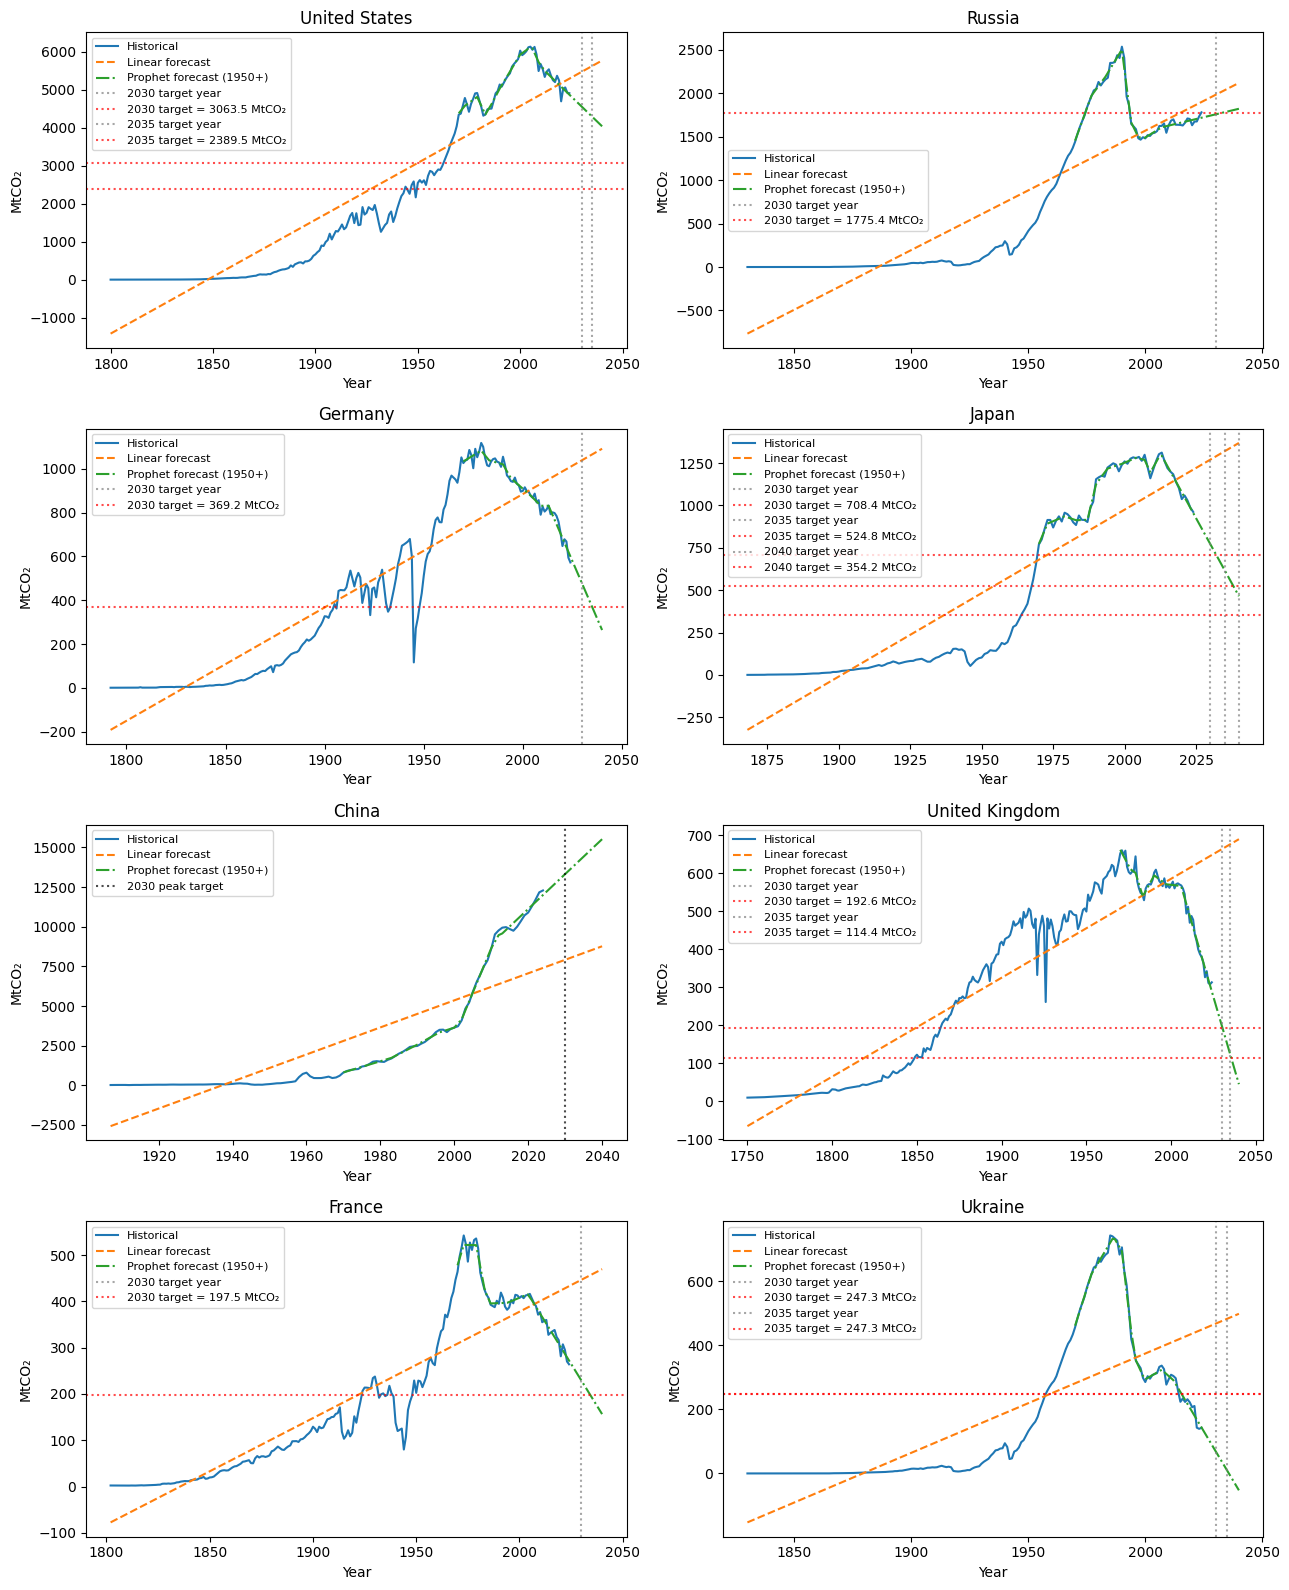

In [ ]:
countries = ["United States", "Russia", "Germany", "Japan", "China", "United Kingdom", "France", "Ukraine"]

n = len(countries)
cols = 2
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(13, 4 * rows))
axes = np.array(axes).reshape(-1)

for i, country in enumerate(countries):
    ax = axes[i]

    country_df = df[df["entity"] == country].copy().sort_values("year")
    model_lin, _ = fit_linear_model(country)

    years_hist = country_df["year"].values
    years_future = np.arange(country_df["year"].min(), 2041)
    preds_lin = model_lin.predict(pd.DataFrame({"year": years_future}))

    model_prophet, prophet_df = fit_prophet(country, start_year=PROPHET_START_YEAR)
    prophet_years = np.arange(PROPHET_START_YEAR, 2041)
    future_prophet = pd.DataFrame({
        "ds": pd.to_datetime([f"{int(y)}-01-01" for y in prophet_years])
    })
    forecast_prophet = model_prophet.predict(future_prophet)

    ax.plot(years_hist, country_df["emissions_mtco2"], label="Historical")
    ax.plot(years_future, preds_lin, linestyle="--", label="Linear forecast")
    ax.plot(forecast_prophet["ds"].dt.year, forecast_prophet["yhat"], linestyle="-.", label="Prophet forecast (1970+)")

    if country != "China":
        country_targets = absolute_targets[absolute_targets["country"] == country].copy().sort_values("target_year")

        for _, row in country_targets.iterrows():
            year = int(row["target_year"])
            target_val = row["target_absolute_mtco2"]

            ax.axvline(year, linestyle=":", color="gray", alpha=0.7,
                       label=f"{year} target year")

            if pd.notna(target_val):
                ax.axhline(target_val, linestyle=":", color="red", alpha=0.7,
                           label=f"{year} target = {target_val:.1f} MtCO₂")
    else:
        ax.axvline(2030, linestyle=":", color="black", alpha=0.7, label="2030 peak target")

    handles, labels = ax.get_legend_handles_labels()
    unique = dict(zip(labels, handles))
    ax.legend(unique.values(), unique.keys(), fontsize=8)

    ax.set_title(country)
    ax.set_xlabel("Year")
    ax.set_ylabel("MtCO₂")

for j in range(len(countries), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


## Prophet interpretation

### Countries with sustained decline (closest to targets)

**Germany**, the **United Kingdom**, **France**, and **Ukraine** exhibit clear post-peak trajectories with sustained emissions decline.

- United Kingdom shows the strongest alignment, with a steep and consistent reduction trend approaching its 2030 and 2035 targets.
- Germany and France follow similar patterns, though both remain slightly above their targets due to insufficient decline speed.
- Ukraine’s Prophet forecast suggests an extremely early net-zero year, driven by a steep recent decline in emissions. However, this result reflects structural shocks rather than sustained decarbonization. Emissions reductions in Ukraine are largely attributable to post-Soviet industrial collapse and recent war-related disruptions, which significantly reduced economic activity and energy use.
As a result, the model extrapolates a rapid decline that is unlikely to represent a stable long-term trajectory. This highlights a key limitation of trend-based forecasting: it cannot distinguish between policy-driven decarbonization and emissions reductions caused by economic contraction or external shocks.

### Countries with insufficient reduction pace

The **United States** and **Japan** have both peaked and entered a declining phase, but the rate of reduction is too slow.

- United States shows a clear downward trend in the Prophet forecast, yet remains significantly above both 2030 and 2035 targets.
- Japan exhibits a plateau followed by gradual decline, failing to meet increasingly stringent targets through 2040.

### Countries with structural or target limitations

**Russia** and **China** illustrate different challenges in interpreting target alignment.

- Russia appears close to its 2030 target; however, this is largely a result of the 1990s emissions collapse and a high baseline. Recent trends show stabilization rather than meaningful decline, indicating limited structural decarbonization.
- China continues on a strong upward trajectory with no observable peak before 2030. Both models project continued growth, suggesting that the peak target requires a significant and currently unobserved structural shift.

### China peak check

In [318]:
china_df = df[df["entity"] == "China"].copy().sort_values("year")

max_row = china_df.loc[china_df["emissions_mtco2"].idxmax()]
max_year = int(max_row["year"])
max_value = float(max_row["emissions_mtco2"])

last_year = int(china_df["year"].max())

print(f"China peak year (observed): {max_year}")
print(f"Last available year: {last_year}")
print(f"Peak emissions: {max_value:.2f} MtCO₂")

if max_year == last_year:
    print("Conclusion: China has NOT peaked yet (peak is at the latest year).")
else:
    print("Conclusion: China may have peaked before the latest year.")

China peak year (observed): 2024
Last available year: 2024
Peak emissions: 12289.04 MtCO₂
Conclusion: China has NOT peaked yet (peak is at the latest year).


The maximum emissions value occurs in the most recent year of the dataset, confirming that China has not yet reached a peak and remains on an upward trajectory.

## Net Zero: Prophet

Now that the Prophet models are trained, we estimate when each country is expected to reach net-zero emissions under current trends.

To do this, we simulate future emissions trajectories year by year up to a defined forecast end year (forecast_end_year) and identify the first year in which predicted emissions fall below the zero threshold.

In [319]:
countries = ["United States", "Russia", "Germany", "Japan", "China", "United Kingdom", "France", "Ukraine"]

def prophet_net_zero_year(country, threshold=0, forecast_end_year=2100, start_year=PROPHET_START_YEAR):
    """
    Estimate the first year in which Prophet forecast falls below a chosen near-zero threshold.
    Returns None if the threshold is never reached by forecast_end_year.
    """
    model, prophet_df = fit_prophet(country, start_year=start_year)

    future_years = np.arange(start_year, forecast_end_year + 1)
    future = pd.DataFrame({
        "ds": pd.to_datetime([f"{int(y)}-01-01" for y in future_years]),
        "floor": [0.0] * len(future_years)
    })

    forecast = model.predict(future).copy()
    yhat = forecast["yhat"].copy()

    result = pd.DataFrame({
        "year": forecast["ds"].dt.year,
        "forecast_mtco2": yhat
    })

    hit = result[result["forecast_mtco2"] <= threshold]

    if len(hit) == 0:
        return None

    return int(hit["year"].iloc[0])


net_zero_results = []

for country in countries:
    predicted_year = prophet_net_zero_year(country, threshold=50, forecast_end_year=2100)

    target_year_series = targets.loc[
        targets["country"] == country, "net_zero_year"
    ].dropna()

    target_year = int(target_year_series.iloc[0]) if len(target_year_series) > 0 else None

    net_zero_results.append({
        "country": country,
        "predicted_net_zero_year_prophet": predicted_year,
        "target_net_zero_year": target_year,
        "on_track_prophet_netzero": (
            predicted_year is not None and target_year is not None and predicted_year <= target_year
        )
    })

net_zero_df = pd.DataFrame(net_zero_results)
net_zero_df

23:46:08 - cmdstanpy - INFO - Chain [1] start processing
23:46:08 - cmdstanpy - INFO - Chain [1] done processing
23:46:09 - cmdstanpy - INFO - Chain [1] start processing
23:46:09 - cmdstanpy - INFO - Chain [1] done processing
23:46:09 - cmdstanpy - INFO - Chain [1] start processing
23:46:09 - cmdstanpy - INFO - Chain [1] done processing
23:46:09 - cmdstanpy - INFO - Chain [1] start processing
23:46:09 - cmdstanpy - INFO - Chain [1] done processing
23:46:09 - cmdstanpy - INFO - Chain [1] start processing
23:46:09 - cmdstanpy - INFO - Chain [1] done processing
23:46:09 - cmdstanpy - INFO - Chain [1] start processing
23:46:09 - cmdstanpy - INFO - Chain [1] done processing
23:46:09 - cmdstanpy - INFO - Chain [1] start processing
23:46:09 - cmdstanpy - INFO - Chain [1] done processing
23:46:10 - cmdstanpy - INFO - Chain [1] start processing
23:46:10 - cmdstanpy - INFO - Chain [1] done processing


,country,predicted_net_zero_year_prophet,target_net_zero_year,on_track_prophet_netzero
0,United States,NaN,2050,False
1,Russia,NaN,2060,False
2,Germany,2051.0,2045,False
3,Japan,2054.0,2050,False
4,China,NaN,2060,False
5,United Kingdom,2040.0,2050,True
6,France,2055.0,2050,False
7,Ukraine,2032.0,2060,True


## Prophet-based net-zero assessment

The Prophet-based net-zero projections highlight a significant gap between current emissions trajectories and stated climate commitments. Only the United Kingdom and Ukraine are projected to reach near-zero emissions before their target years. However, while the UK reflects a sustained, policy-driven decline, Ukraine’s early net-zero projection is driven by structural shocks rather than stable decarbonization.

For Germany, Japan, and France, the model predicts net-zero years slightly beyond their targets, indicating that current reduction rates are insufficient despite clear downward trends. In contrast, the United States, Russia, and China do not reach near-zero emissions within the forecast horizon, suggesting that under current trajectories they are not on a credible path toward their net-zero commitments.